In [93]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

In [94]:
df = pd.read_csv('loan_data.csv')

In [95]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [96]:
df.info()    

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

In [97]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [98]:
numeric_columns_int = df.select_dtypes('int')
numeric_columns_float = df.select_dtypes('float')
categorical_columns = df.select_dtypes('str')

# person_emp_exp
# person_age

In [99]:
# for x in categorical_columns:
#     sns.countplot(  
#                     data = df,
#                     y = x,
#     )
#     plt.show()

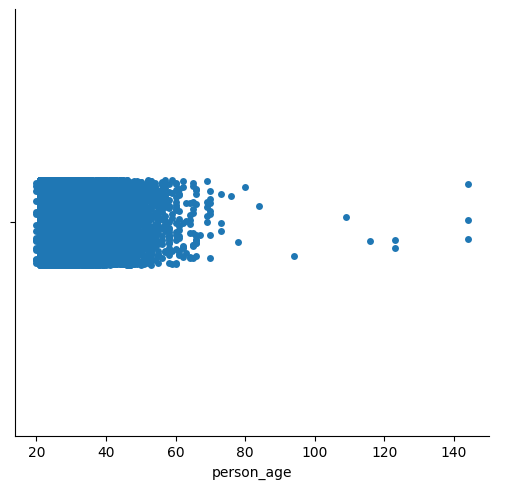

In [100]:
# plt.figure(figsize=(30,10))
sns.catplot(
                    data = df,
                    x = 'person_age'
    )
plt.show()

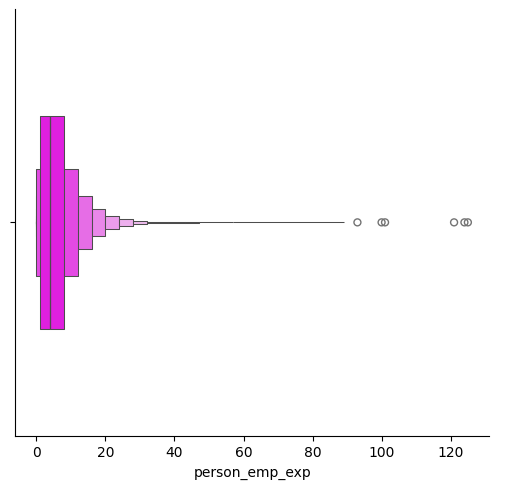

In [101]:
sns.catplot(
                    data = df,
                    x = 'person_emp_exp',
                    width = 0.5,
                    color = 'magenta',
                    kind = 'boxen'
    )
plt.show()

In [102]:
df[df['person_age']>100]

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
81,144.0,male,Bachelor,300616.0,125,RENT,4800.0,VENTURE,13.57,0.02,3.0,789,No,0
183,144.0,male,Associate,241424.0,121,MORTGAGE,6000.0,EDUCATION,11.86,0.02,2.0,807,No,0
575,123.0,female,High School,97140.0,101,RENT,20400.0,EDUCATION,10.25,0.21,3.0,805,Yes,0
747,123.0,male,Bachelor,94723.0,100,RENT,20000.0,VENTURE,11.01,0.21,4.0,714,Yes,0
32297,144.0,female,Associate,7200766.0,124,MORTGAGE,5000.0,PERSONAL,12.73,0.00,25.0,850,No,0
37930,116.0,male,Bachelor,5545545.0,93,MORTGAGE,3823.0,VENTURE,12.15,0.00,24.0,708,No,0
38113,109.0,male,High School,5556399.0,85,MORTGAGE,6195.0,VENTURE,12.58,0.00,22.0,792,No,0


In [103]:
df[df['person_emp_exp']>100]

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
81,144.0,male,Bachelor,300616.0,125,RENT,4800.0,VENTURE,13.57,0.02,3.0,789,No,0
183,144.0,male,Associate,241424.0,121,MORTGAGE,6000.0,EDUCATION,11.86,0.02,2.0,807,No,0
575,123.0,female,High School,97140.0,101,RENT,20400.0,EDUCATION,10.25,0.21,3.0,805,Yes,0
32297,144.0,female,Associate,7200766.0,124,MORTGAGE,5000.0,PERSONAL,12.73,0.00,25.0,850,No,0


In [104]:
df[(df['person_age'] < 100) & (df['person_emp_exp'] < 100 )]

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [105]:
df  = df[(df['person_age'] < 100) & (df['person_emp_exp'] < 100 )]

In [106]:
# We have to repeat all the steps till the column transformer and make sure we dont fit/transform anything.
X = df.drop(columns = ['loan_status'])
y = df['loan_status']

X_train , X_test , y_train , y_test = train_test_split ( X , y , test_size = 0.2 , random_state = 42 )

categories_without_order = ['person_gender','person_home_ownership','loan_intent','previous_loan_defaults_on_file']
categories_with_order = ['person_education']
person_education_order = [ [  'High School', 'Bachelor', 'Master', 'Associate', 'Doctorate' ] ]

# When deploying we just take the pipe , the pipe remembers all the columns and we dont need to explicitly pass the category tuple
column_transformer1 = ColumnTransformer(
                                            transformers = [
                                                               ( 'ohe', OneHotEncoder(sparse_output=False , drop = 'first' ) , categories_without_order ),
                                                               ( 'ord', OrdinalEncoder(categories = person_education_order ) , categories_with_order ),
                                                               ('scale_num', StandardScaler(), ['loan_amnt','person_income'])
                                            ] ,
                                            remainder = 'passthrough'
)



# Building pipeline
pipe = Pipeline(
                [
                    ( 'preprocessor' , column_transformer1 ),
                    (  'xgbc_model' , XGBClassifier(
                                                        scale_pos_weight = y.value_counts()[0] / y.value_counts()[1],# To handle the imbalance y column
                                                        n_estimators = 150, #100
                                                        max_depth = 10, #7 8
                                                        eta = 0.3, #0.1
                                                        objective = 'binary:logistic',
                                                        random_state = 42, 
                                                        verbosity = 1,
                                                        n_jobs = -1 
                    ) )
                ]
)

In [107]:
# Fitting pipeline 
pipe.fit(X_train,y_train)

#Making predictions
y_pred = pipe.predict(X_test)

In [108]:
# Now lets evaluate the same 
scores = cross_val_score(pipe.named_steps['xgbc_model'] , pipe.named_steps['preprocessor'].fit_transform(X), y , cv = 10, scoring = 'accuracy' ).mean()
scores

np.float64(0.9232781852757403)

In [109]:
accuracy_score(y_test,y_pred)

0.9284364929436604

In [110]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      0.95      0.95      7002
           1       0.84      0.84      0.84      1997

    accuracy                           0.93      8999
   macro avg       0.90      0.90      0.90      8999
weighted avg       0.93      0.93      0.93      8999



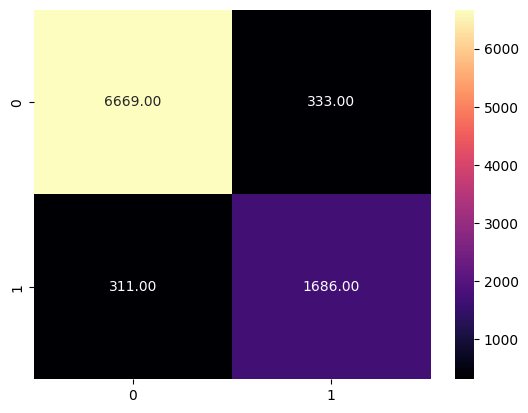

In [111]:
sns.heatmap(
                data = pd.DataFrame(confusion_matrix(y_test,y_pred)),
                annot = True,
                cmap = 'magma',
                fmt='.2f'
)
plt.show()

In [112]:
# Before Exporting the model always make sure we are fitting the model with the whole dataset at the end 

In [113]:
# pipe.fit(X,y)

In [114]:
# y_pred_X = pipe.predict(X)

In [115]:
# accuracy_score(y,y_pred_X)

In [116]:
# print(classification_report(y,y_pred_X))

In [117]:
# sns.heatmap(
#                 data = pd.DataFrame(confusion_matrix(y,y_pred_X)),
#                 annot = True,
#                 cmap = 'magma',
#                 fmt='.2f'
# )
# plt.show()

In [118]:
# import joblib

In [119]:
# model_path = 'models/xgb_loan_pipeline_v1.pkl'
# joblib.dump(pipe,model_path,compress=3)
# print(f'The Engined was saved successfully at {model_path}')